In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor



In [5]:
df = pd.read_csv(r"C:\Users\Khan\OneDrive\Desktop\Intern_Performance_prediction\intern_dataset.csv")

In [ ]:
df.head()

,Intern_ID,Completion_Time,Feedback_Rating,Attendance,Performance_Score
0,INT0001,3.26,4.09,86.50,70.98
1,INT0002,NaN,1.33,59.23,42.16
2,INT0003,5.78,NaN,42.98,49.89
3,INT0004,4.28,1.43,83.16,68.49
4,INT0005,1.53,1.91,74.10,77.51


In [6]:
df.isnull().sum()

Intern_ID              0
Completion_Time      396
Feedback_Rating      392
Attendance           390
Performance_Score      0
dtype: int64

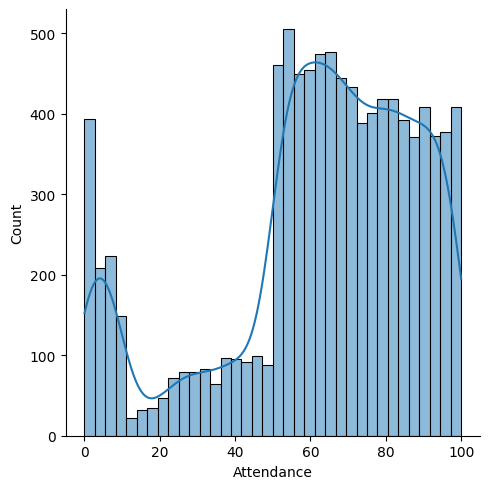

In [7]:
sns.displot(df['Attendance'], kde=True)
plt.show()

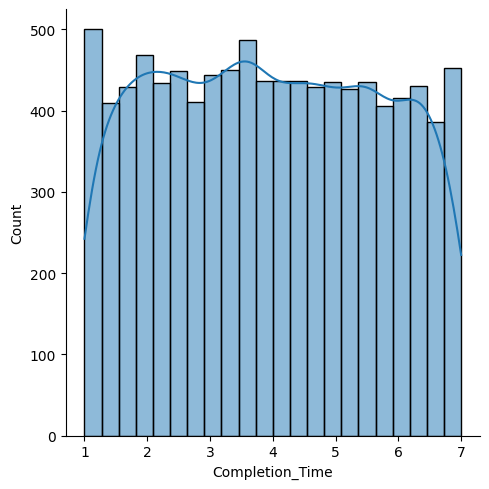

In [9]:
sns.displot(df['Completion_Time'], kde=True)
plt.show()

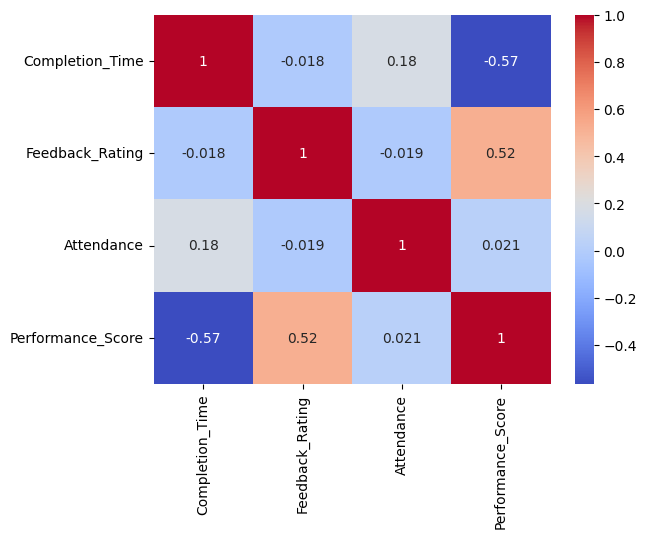

In [8]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Text(0.5, 1.0, 'Performance Score Distribution')

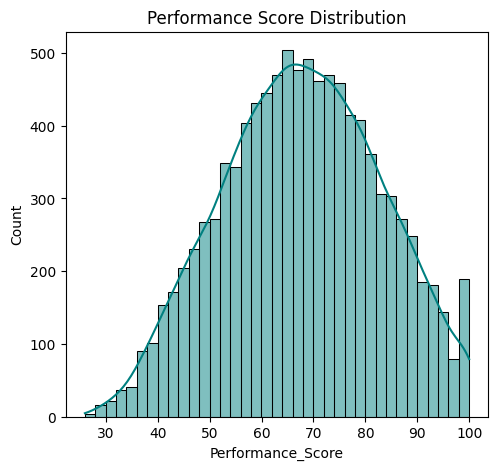

In [10]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Performance_Score'], kde=True, color='teal')
plt.title('Performance Score Distribution')

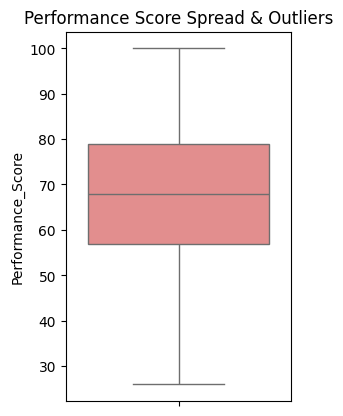

In [11]:
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Performance_Score'], color='lightcoral')
plt.title('Performance Score Spread & Outliers')
plt.show()

In [12]:
df = df.drop(columns=["Attendance","Intern_ID"])

In [13]:
df.head()

,Completion_Time,Feedback_Rating,Performance_Score
0,3.26,4.09,70.98
1,NaN,1.33,42.16
2,5.78,NaN,49.89
3,4.28,1.43,68.49
4,1.53,1.91,77.51


In [ ]:
df.isnull().sum()

Completion_Time      396
Feedback_Rating      392
Performance_Score      0
dtype: int64

In [15]:
cols_to_fix = ['Completion_Time', 'Feedback_Rating']
data_subset = df[cols_to_fix]
imputer = IterativeImputer(max_iter=10, random_state=0)
imputed_data = imputer.fit_transform(data_subset)

In [16]:
df.isnull().sum()

Completion_Time      396
Feedback_Rating      392
Performance_Score      0
dtype: int64

In [17]:
df[cols_to_fix] = imputer.fit_transform(df[cols_to_fix])

In [18]:
df.head()

,Completion_Time,Feedback_Rating,Performance_Score
0,3.260000,4.090000,70.98
1,3.986577,1.330000,42.16
2,5.780000,2.890703,49.89
3,4.280000,1.430000,68.49
4,1.530000,1.910000,77.51


In [19]:
df.isnull().sum()

Completion_Time      0
Feedback_Rating      0
Performance_Score    0
dtype: int64

In [20]:
df["Efficiency"] = df["Feedback_Rating"] / df["Completion_Time"]

In [21]:
df.head()

,Completion_Time,Feedback_Rating,Performance_Score,Efficiency
0,3.260000,4.090000,70.98,1.254601
1,3.986577,1.330000,42.16,0.333620
2,5.780000,2.890703,49.89,0.500122
3,4.280000,1.430000,68.49,0.334112
4,1.530000,1.910000,77.51,1.248366


In [22]:
df.isnull().sum()

Completion_Time      0
Feedback_Rating      0
Performance_Score    0
Efficiency           0
dtype: int64

In [23]:
df.describe()

,Completion_Time,Feedback_Rating,Performance_Score,Efficiency
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.958590,2.909296,67.808159,0.956975
std,1.703515,1.286838,15.170590,0.773425
min,1.000000,1.000000,25.950000,0.142857
25%,2.520000,1.800000,56.947500,0.447597
50%,3.952553,2.900000,67.830000,0.736553
75%,5.380000,3.970000,78.870000,1.183762
max,7.000000,5.000000,100.000000,5.000000


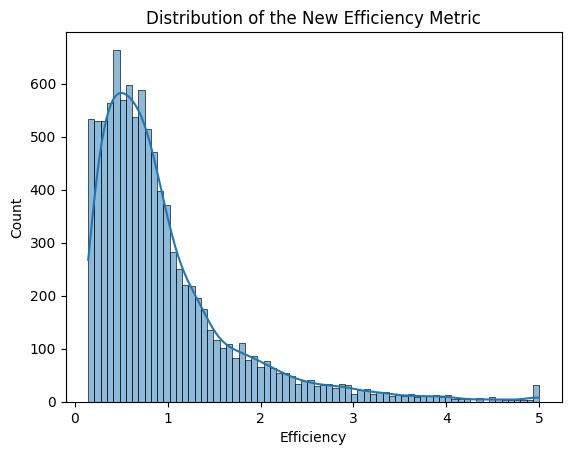

In [24]:
sns.histplot(df['Efficiency'], kde=True)
plt.title("Distribution of the New Efficiency Metric")
plt.show()

In [25]:
X = df[["Completion_Time", "Feedback_Rating", "Efficiency"]]
y = df["Performance_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [28]:
xgb_model = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=42,
    objective='reg:squarederror'
)

xgb_model.fit(X_train, y_train)

# 4. Predict and Evaluate
xgb_preds = xgb_model.predict(X_test)

print(f"XGBoost R2: {r2_score(y_test, xgb_preds):.3f}")
print(f"XGBoost MAE: {mean_absolute_error(y_test, xgb_preds):.3f}")
print(f"XGBoost MSE: {mean_squared_error(y_test, xgb_preds):.3f}")

XGBoost R2: 0.572
XGBoost MAE: 7.911
XGBoost MSE: 96.516


In [29]:
rf_preds = rf_model.predict(X_test)
gb_preds = gb_model.predict(X_test)

print(f"Random Forest R2: {r2_score(y_test, rf_preds):.3f}")
print(f"Random Forest MSE: {mean_squared_error(y_test, rf_preds):.3f}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, rf_preds):.3f}")
print(f"Gradient Boosting R2: {r2_score(y_test, gb_preds):.3f}")
print(f"Gradient Boosting MAE: {mean_absolute_error(y_test, gb_preds):.3f}")
print(f"Gradient Boosting MSE: {mean_squared_error(y_test, gb_preds):.3f}")


Random Forest R2: 0.487
Random Forest MSE: 115.784
Random Forest MAE: 8.641
Gradient Boosting R2: 0.579
Gradient Boosting MAE: 7.861
Gradient Boosting MSE: 94.946


           Feature  Importance
2       Efficiency    0.870188
1  Feedback_Rating    0.079717
0  Completion_Time    0.050095


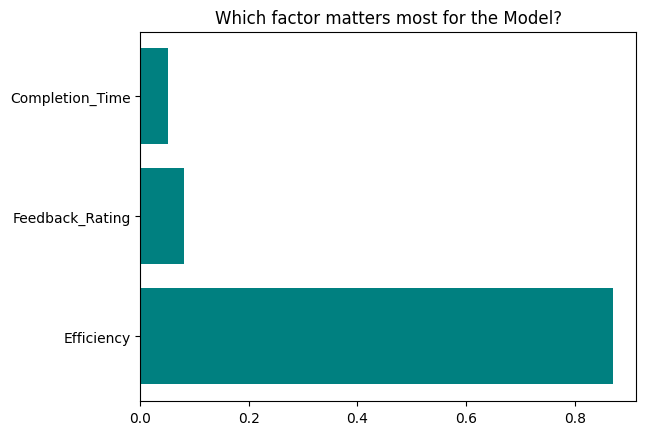

In [ ]:
importances = gb_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df)

# Visualize it
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='teal')
plt.title('Which factor matters most for the Model?')
plt.show()

In [30]:
# 1. Use your trained model to predict scores for everyone
df['Predicted_Score'] = gb_model.predict(X)

# 2. Define the thresholds based on percentiles
lower_threshold = df['Predicted_Score'].quantile(0.20) # Bottom 20%
upper_threshold = df['Predicted_Score'].quantile(0.80) # Top 20%

# 3. Create the categorization function
def categorize(score):
    if score >= upper_threshold:
        return 'Excel'
    elif score <= lower_threshold:
        return 'Struggle'
    else:
        return 'Average'

# 4. Apply categorization to a new column
df['Performance_Category'] = df['Predicted_Score'].apply(categorize)

# 5. Filter for your "Action Lists"
excel_interns = df[df['Performance_Category'] == 'Excel']
struggle_interns = df[df['Performance_Category'] == 'Struggle']

print(f"Number of interns likely to Excel: {len(excel_interns)}")
print(f"Number of interns likely to Struggle: {len(struggle_interns)}")

Number of interns likely to Excel: 2000
Number of interns likely to Struggle: 2004


C:\Users\Khan\AppData\Local\Temp\ipykernel_6588\1148391528.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Performance_Category', y='Efficiency', data=df, palette='viridis')


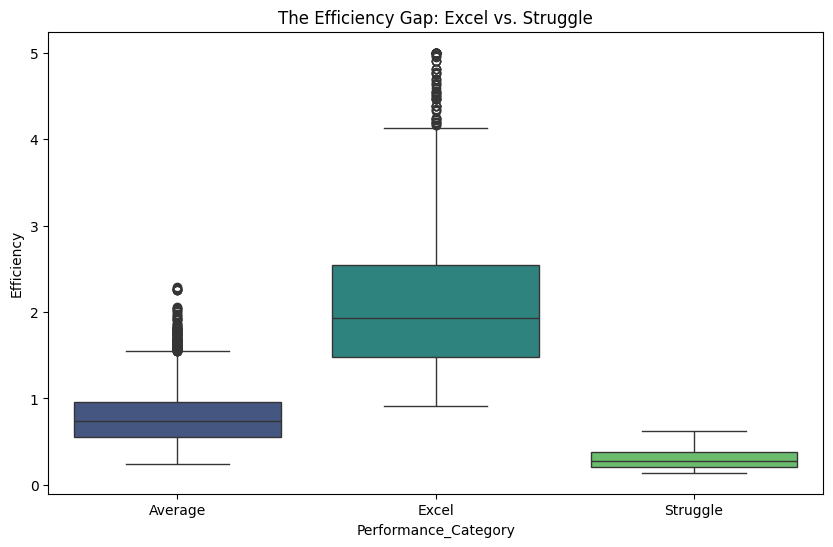

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='Performance_Category', y='Efficiency', data=df, palette='viridis')
plt.title('The Efficiency Gap: Excel vs. Struggle')
plt.show()